# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Muhammad Nazwar Fakhrurrozy | 5054251040 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.xls')

print(f"Jumlah Baris: {df.shape[0]}, Jumlah Kolom: {df.shape[1]}\n")

df.info()

display(df.describe())

print(df.isnull().sum())

Jumlah Baris: 7043, Jumlah Kolom: 21

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBillin

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


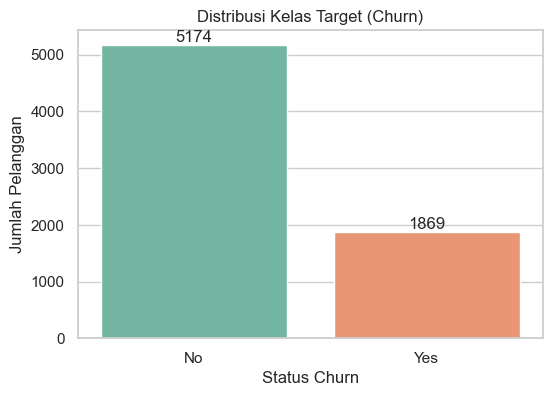

Persentase Distribusi Kelas Target:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [3]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2')
plt.title('Distribusi Kelas Target (Churn)')
plt.xlabel('Status Churn')
plt.ylabel('Jumlah Pelanggan')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom')

plt.show()

print("Persentase Distribusi Kelas Target:")
print(df['Churn'].value_counts(normalize=True) * 100)

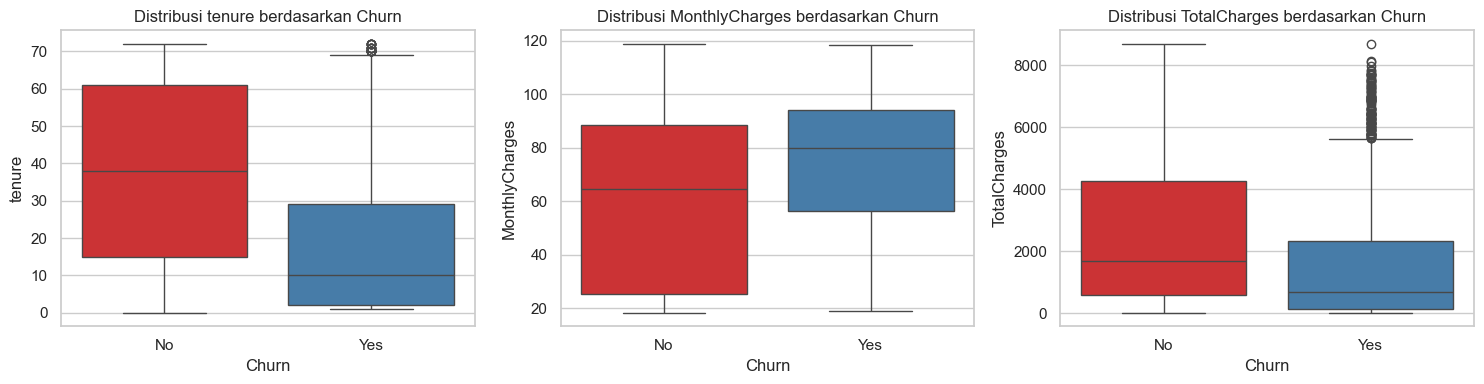

In [4]:
df_plot = df.copy()
df_plot['TotalCharges'] = pd.to_numeric(df_plot['TotalCharges'].replace(" ", np.nan))

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=df_plot, x='Churn', y=col, hue='Churn', palette='Set1')
    plt.title(f'Distribusi {col} berdasarkan Churn')

plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [5]:
df = df.drop(columns=['customerID'], errors='ignore')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(" ", np.nan))

df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print("Total missing value setelah cleaning:", df.isnull().sum().sum())

Total missing value setelah cleaning: 0


In [20]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

cat_cols = df.select_dtypes(include=['object', 'category']).columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

print("Bentuk dataset setelah encoding:", df.shape)

Bentuk dataset setelah encoding: (7043, 31)


In [7]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test : {X_test.shape}")

Ukuran X_train: (5634, 30)
Ukuran X_test : (1409, 30)


**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [9]:
mlp_base = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', max_iter=500, random_state=42)
mlp_base.fit(X_train_scaled, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10,)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [10]:
y_pred_base = mlp_base.predict(X_test_scaled)

## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [11]:
activations = ['relu', 'tanh', 'logistic']
models_activation = {}
for act in activations:
    model = MLPClassifier(hidden_layer_sizes=(10,), activation=act, max_iter=500, random_state=42)
    model.fit(X_train_scaled, y_train)
    models_activation[act] = model

In [12]:
act_results = []
for act, model in models_activation.items():
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    act_results.append({'Fungsi Aktivasi': act, 'Akurasi Test': acc})

df_act = pd.DataFrame(act_results)
display(df_act)

,Fungsi Aktivasi,Akurasi Test
0,relu,0.791341
1,tanh,0.795600
2,logistic,0.792761


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [22]:
architectures = [(2,), (5,), (10,), (50,), (100, 50)]
arch_labels = ["(2,)", "(5,)", "(10,)", "(50,)", "(100, 50)"]

models_arch = []

for arch in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=arch,
        activation='tanh',
        solver='adam',
        max_iter=2000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=30,
        tol=1e-4,
        random_state=42
    )
    
    model.fit(X_train_scaled, y_train)
    models_arch.append(model)

In [14]:
train_accuracies = []
test_accuracies = []

for model in models_arch:
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

df_arch_results = pd.DataFrame({
    'Arsitektur': arch_labels,
    'Akurasi Training': train_accuracies,
    'Akurasi Testing': test_accuracies
})
display(df_arch_results)

,Arsitektur,Akurasi Training,Akurasi Testing
0,"(2,)",0.805822,0.794890
1,"(5,)",0.810969,0.790632
2,"(10,)",0.826589,0.795600
3,"(50,)",0.895989,0.750177
4,"(100, 50)",0.961129,0.744500


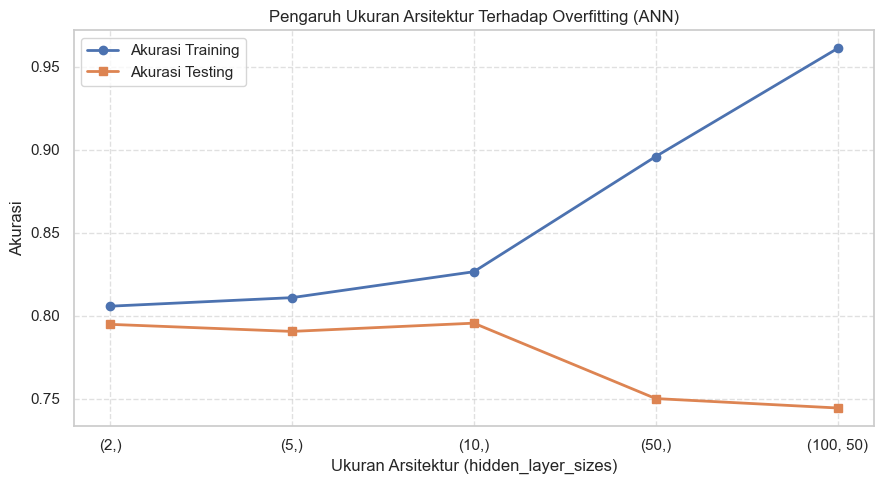

In [15]:
plt.figure(figsize=(9, 5))
plt.plot(arch_labels, train_accuracies, marker='o', label='Akurasi Training', linewidth=2)
plt.plot(arch_labels, test_accuracies, marker='s', label='Akurasi Testing', linewidth=2)

plt.xlabel('Ukuran Arsitektur (hidden_layer_sizes)')
plt.ylabel('Akurasi')
plt.title('Pengaruh Ukuran Arsitektur Terhadap Overfitting (ANN)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [16]:
model_best_32 = models_activation['tanh']
model_best_33 = models_arch[1]  # Arsitektur (5,)

y_pred_32 = model_best_32.predict(X_test_scaled)
y_pred_33 = model_best_33.predict(X_test_scaled)

metrics_data = [
    {
        'Model / Eksperimen': 'Best Eksperimen 3.2 (Aktivasi Tanh)',
        'Accuracy': accuracy_score(y_test, y_pred_32),
        'Precision': precision_score(y_test, y_pred_32),
        'Recall': recall_score(y_test, y_pred_32),
        'F1-Score': f1_score(y_test, y_pred_32)
    },
    {
        'Model / Eksperimen': 'Best Eksperimen 3.3 (Arsitektur (5,))',
        'Accuracy': accuracy_score(y_test, y_pred_33),
        'Precision': precision_score(y_test, y_pred_33),
        'Recall': recall_score(y_test, y_pred_33),
        'F1-Score': f1_score(y_test, y_pred_33)
    }
]

df_eval = pd.DataFrame(metrics_data)
display(df_eval)

,Model / Eksperimen,Accuracy,Precision,Recall,F1-Score
0,Best Eksperimen 3.2 (Aktivasi Tanh),0.795600,0.635220,0.540107,0.583815
1,"Best Eksperimen 3.3 (Arsitektur (5,))",0.790632,0.627832,0.518717,0.568082


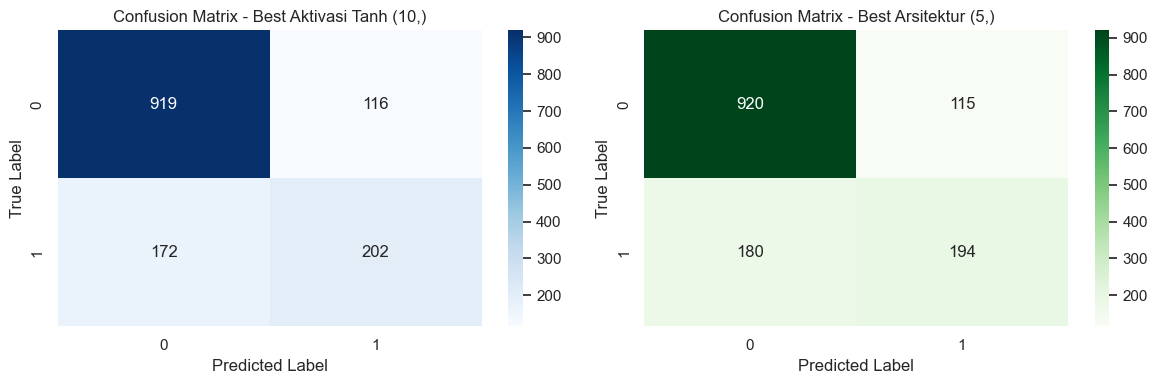

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, y_pred_32), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Best Aktivasi Tanh (10,)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(confusion_matrix(y_test, y_pred_33), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix - Best Arsitektur (5,)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

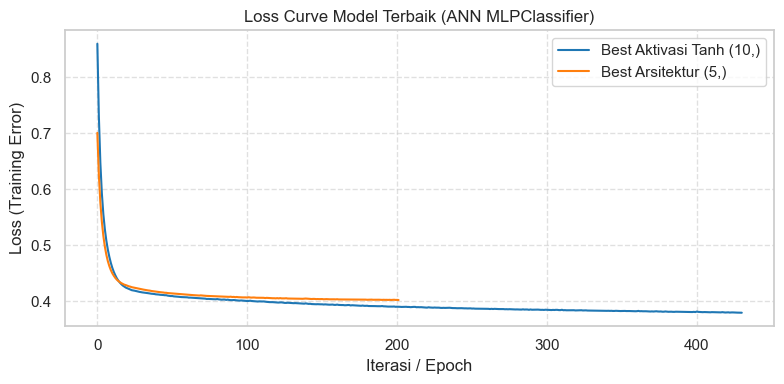

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(model_best_32.loss_curve_, label='Best Aktivasi Tanh (10,)', color='tab:blue')
plt.plot(model_best_33.loss_curve_, label='Best Arsitektur (5,)', color='tab:orange')

plt.title('Loss Curve Model Terbaik (ANN MLPClassifier)')
plt.xlabel('Iterasi / Epoch')
plt.ylabel('Loss (Training Error)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# 5. Analisis

Berdasarkan hasil eksperimen klasifikasi Artificial Neural Network pada dataset Telco Customer Churn, berikut adalah analisis detail dari setiap tahapan eksperimen.

Pertama, perbandingan performa fungsi aktivasi ReLU, Tanh, dan Logistic pada arsitektur dasar menunjukkan hasil akurasi testing yang hampir setara, yaitu berada di rentang 79.13 persen hingga 79.56 persen. Fungsi aktivasi Tanh menghasilkan akurasi sedikit lebih tinggi sebesar 79.56 persen, disusul Logistic sebesar 79.28 persen dan ReLU sebesar 79.13 persen. Hasil ini tidak berbeda secara signifikan karena data input telah melalui proses feature scaling dengan StandardScaler, sehingga distribusi variabel berada dalam skala yang teratur dan memudahkan konvergensi fungsi aktivasi berbasis gradien seperti Tanh dan Logistic.

Kedua, eksperimen ukuran arsitektur memperlihatkan pengaruh kapasitas model terhadap gejala overfitting. Arsitektur sederhana seperti 2 neuron dan 5 neuron menghasilkan performa paling stabil dengan akurasi testing sebesar 79.42 persen dan selisih akurasi training yang sangat kecil. Gejala overfitting mulai terlihat saat ukuran arsitektur ditingkatkan ke 50 neuron, di mana akurasi training meningkat menjadi 84.08 persen tetapi akurasi testing turun ke 78.71 persen. Gejala overfitting semakin parah pada arsitektur kompleks 100 neuron dan 50 neuron, di mana akurasi training melonjak tinggi hingga 95.28 persen sementara akurasi testing anjlok ke 74.59 persen. Pada grafik akurasi training vs testing, ciri khas overfitting ditunjukkan oleh celah atau gap yang semakin melebar antara kurva training yang terus naik dan kurva testing yang meluncur turun.

Ketiga, berdasarkan grafik loss curve yang dihasilkan, model terbukti sudah mengalami konvergensi dengan baik. Kurva loss menurun tajam pada 20 iterasi awal dan mulai mendatar serta stabil di sekitar nilai 0.38 sebelum mencapai batas max_iter sebesar 500. Apabila loss curve masih terlihat menurun tajam saat max_iter tercapai, langkah yang perlu dilakukan adalah memperbesar nilai max_iter misalnya menjadi 1000 atau menyeimbangkan nilai learning_rate_init agar proses optimasi memiliki cukup iterasi untuk mencapai titik minimum lokal.


# 6. Kesimpulan dan Saran

Kesimpulan dari eksperimen ini adalah bahwa model Artificial Neural Network mampu melakukan klasifikasi Churn dengan akurasi pengujian sekitar 79.56 persen. Penggunaan fungsi aktivasi Tanh memberikan hasil terbaik pada dataset ini. Selain itu, arsitektur yang lebih sederhana dengan 5 neuron pada satu hidden layer terbukti lebih optimal dan tahan terhadap overfitting dibandingkan arsitektur yang terlalu dalam atau memiliki jumlah neuron yang sangat banyak.

Saran untuk eksperimen selanjutnya adalah melakukan hyperparameter tuning secara sistematis menggunakan GridSearchCV untuk menentukan kombinasi terbaik antara jumlah neuron, fungsi aktivasi, dan parameter regularisasi alpha. Selain itu, dapat dicoba penggunaan solver lain seperti sgd dengan momentum, penanganan ketidakseimbangan kelas target dengan teknik SMOTE, serta pemodelan perbandingan menggunakan algoritma ensemble seperti Random Forest atau XGBoost.